### ECON5140 Homework 3
Helen Dong

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

In [2]:
np.random.seed(123)

In [3]:
# Simulated data: AI assistant feature rollout (phased, not random)
n = 600
plan_tier = np.random.choice([0, 1, 2], n, p=[0.5, 0.35, 0.15])
tenure_days = np.random.randint(0, 366, n)
prior_sessions = np.random.poisson(12, n) + np.random.randint(0, 20, n)
platform = np.random.choice([0, 1], n, p=[0.6, 0.4])
signup_cohort = np.random.choice([0, 1, 2], n, p=[0.4, 0.35, 0.25])

# Treatment: higher tier, tenure, prior sessions, mobile → more likely to get feature
logit_p = -2.0 + 0.5*plan_tier + 0.003*tenure_days + 0.02*prior_sessions + 0.4*platform + 0.2*signup_cohort
ps_true = 1 / (1 + np.exp(-np.clip(logit_p, -10, 10)))
D = (np.random.uniform(0, 1, n) < ps_true).astype(int)

# Outcome: weekly_active_minutes. True effect of feature = +15 min
Y = 80 + 15*D + 8*plan_tier + 0.05*tenure_days + 0.8*prior_sessions + 5*platform + 3*signup_cohort + np.random.normal(0, 12, n)
Y = np.maximum(Y, 0)

df = pd.DataFrame({
    'plan_tier': plan_tier, 'tenure_days': tenure_days, 'prior_sessions': prior_sessions,
    'platform': platform, 'signup_cohort': signup_cohort, 'D': D, 'weekly_active_minutes': Y
})

print("Dataset: AI assistant feature rollout")
print(f"  n = {len(df)}, Treated: {D.sum()}, Control: {n - D.sum()}")
print(f"  True causal effect: +15 min/week")
print(df.head(10))

Dataset: AI assistant feature rollout
  n = 600, Treated: 254, Control: 346
  True causal effect: +15 min/week
   plan_tier  tenure_days  prior_sessions  platform  signup_cohort  D  \
0          1          231              16         1              2  0   
1          0          276              28         0              2  0   
2          0          345              21         0              1  1   
3          1          353              23         0              1  1   
4          1           39              15         0              0  0   
5          0          205              28         0              0  0   
6          2          298              17         0              0  0   
7          1           58              31         0              0  1   
8          0           48              14         1              2  0   
9          0          174               9         0              2  0   

   weekly_active_minutes  
0             132.725826  
1             114.294894  
2   

##### 1. Fit logistic regression: D ~ covariates

In [6]:
# prepare to use sklearn

covariates = ['plan_tier', 'tenure_days', 'prior_sessions', 'platform', 'signup_cohort']
X = df[covariates]
y = df['D']

In [7]:
# fit model

lr = LogisticRegression(penalty=None, max_iter=1000)
lr.fit(X, y)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


##### 2. Add df['ps'] = fitted propensity scores

In [8]:
# get propensity scores from the model

df['ps'] = lr.predict_proba(X)[:, 1]

##### 3. Plot overlap (KDE or histogram)

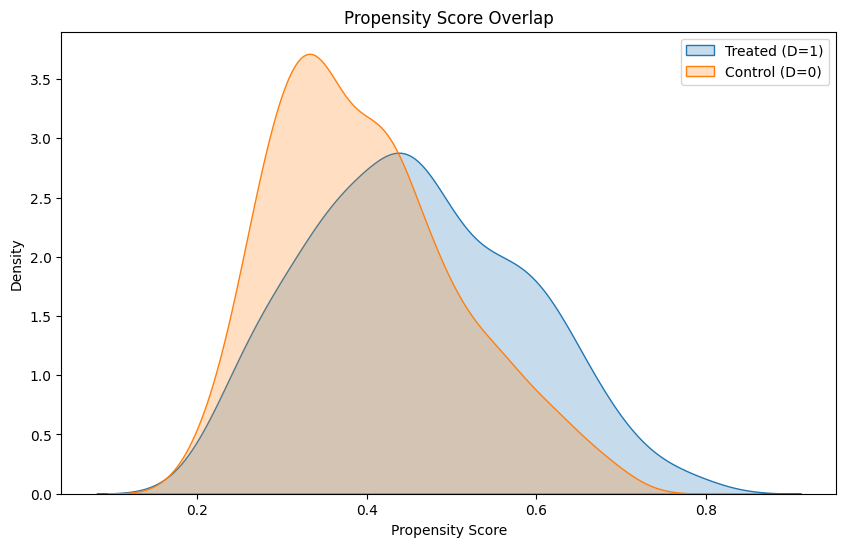

In [12]:
# plot KDE

plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['D'] == 1]['ps'], label='Treated (D=1)', shade=True)
sns.kdeplot(df[df['D'] == 0]['ps'], label='Control (D=0)', shade=True)
plt.title('Propensity Score Overlap')
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.legend()
plt.show()

##### 4. Compute ATE via IPW (clip ps to avoid extreme weights)

In [13]:
# clip propensity score

df['ps_clipped'] = df['ps'].clip(0.05, 0.95)

In [14]:
# calculate ATE weight for each unit

df['weights'] = (df['D'] / df['ps_clipped']) + ((1 - df['D']) / (1 - df['ps_clipped']))

In [15]:
# compute weighted ATE

weighted_avg_treated = (df['weekly_active_minutes'] * df['D'] / df['ps_clipped']).sum() / (df['D'] / df['ps_clipped']).sum()
weighted_avg_control = (df['weekly_active_minutes'] * (1 - df['D']) / (1 - df['ps_clipped'])).sum() / ((1 - df['D']) / (1 - df['ps_clipped'])).sum()
ipw_ate = weighted_avg_treated - weighted_avg_control

##### 5. Compare naive ATE, IPW ATE, true effect (15)

In [16]:
# compute

naive_ate = df[df['D'] == 1]['weekly_active_minutes'].mean() - df[df['D'] == 0]['weekly_active_minutes'].mean()
true_effect = 15

In [17]:
print(f"Naive ATE: {naive_ate:.4f}")
print(f"IPW ATE:   {ipw_ate:.4f}")
print(f"True Effect: {true_effect}")

Naive ATE: 18.7976
IPW ATE:   15.3332
True Effect: 15
